# 1. Introduction

This notebook implements a **Naive Bayes classifier** that categorizes each email as **spam** or **ham**.

## Naive Bayes for the TREC06 Corpus

The classifier is trained on a subset of the TREC06 Public Spam Corpus, a benchmark dataset for spam filtering.

## Setting Up: Input Files

The input files are stored in `./trec06p-ai201`.

### Dataset Directory Structure
```
trec06p-ai201/
├── data/
│   ├── 000/
│   │   ├── 000
│   │   ├── 001
│   │   └── …
│   ├── 001/
│   └── …
│       └── 126/
└── labels
```
### Relative Path Format

```
../data//
```
Each line in `labels` maps a class to a relative file path using the format:
`spam/ham ../url`

**Example:**
```
ham ../data/000/000
spam ../data/000/001
```



## Adding the Dataset Source Path

Set `source = '(your own source path)'`, or define the path through environment variables, then run the cell. If no path is provided, the code defaults to the project root.

You may also copy the dataset directly into the root directory. Make sure the dataset follows the directory structure shown above.

After updating `source`, run the snippet below.



In [1]:
# source = userdata.get('SourcePath') # for local file, use below:
source = 'trec06p-ai201'
!ls -R "{source}" | head -n 10 
print("...")


data
labels
predictions_cache.csv
vocabs.csv

trec06p-ai201/data:
000
001
002
003
ls: stdout: Undefined error: 0
...


## Initialize the input files

Labels are organized into the following structures:

1. File labels: `labels`
2. Ham file list: `hamfiles`
3. Spam file list: `spamfiles`

The data mapping uses pairs in the form `[iii, jjj]`, where:

- `iii` is the folder index
- `jjj` is the file index

Run the snippet below to initialize the dataset.



In [2]:
import os
ham = set()
spam = set()
tests = set() #iii only

labels = os.path.join(source, 'labels')

if os.path.exists(labels):
    with open(labels, 'r') as f:
        for line in f:
            # ['ham', '../data/000/000']
            parts = line.strip().split()
            if len(parts) == 2:
                label = parts[0]
                path_str = parts[1]

                # '../data/000/000'
                partsplit = path_str.split('/')
                iii = partsplit[-2] # folder index
                jjj = partsplit[-1] # file index

                address = (iii, jjj) #tuple
                tests.add(iii) #add folder
                if label == 'ham':
                    ham.add(address)
                elif label == 'spam':
                    spam.add(address)

    limit = 5
    hamfiles = list(ham)
    spamfiles = list(spam)
    tests = sorted(tests)

    print(f"Total Tests (folders): {len(tests)}")
    print(f"")
    print(f"Total Ham entries: {len(ham)}")
    print("Ex:", hamfiles[:limit], "..." if len(hamfiles) > limit else "")
    print(f"")
    print(f"Total Spam entries: {len(spam)}")
    print("Ex:", spamfiles[:limit], "..." if len(spamfiles) > limit else "")
else:
    print(f"Labels file not found at {labels}")

Total Tests (folders): 127

Total Ham entries: 12910
Ex: [('100', '034'), ('060', '235'), ('063', '120'), ('032', '174'), ('006', '047')] ...

Total Spam entries: 24912
Ex: [('074', '109'), ('112', '196'), ('002', '248'), ('056', '234'), ('048', '124')] ...


# 2. Naive Bayes Formula

Naive Bayes assumes conditional independence among words and computes class probabilities from observed word likelihoods.

The formula is as follows:

$$ P(C_k \mid X) = \frac{P(X \mid C_k)\,P(C_k)}{P(X)} $$

Where:

* $P(...)$ is probability
* $P(C_k \mid X)$ is the posterior probability
* $P(C_k)$ is the prior probability from the training data
* $P(x_i \mid C_k)$ is the likelihood of word $x_i$ given class $C_k$
* $C_k$ is the class
 * $C_1=$ `ham`
 * $C_2=$ `spam`
* $x_i$ are words (features)
* $n$ is the total number of words

The full formula that multiplies all word likelihoods is:

$$P(C_k \mid X) =
\frac{\left( \prod_{i=1}^{n} P(x_i \mid C_k) \right) P(C_k)}
{\sum_{j=1}^{K} \left( \prod_{i=1}^{n} P(x_i \mid C_j) \right) P(C_j)}$$

## Lambda Smoothing

If a word does not appear in the training vocabulary, its probability can become zero and collapse the full product. To avoid this, Laplace smoothing with parameter $\lambda$ is applied:

$$
P(x_i \mid C_k) =
\frac{N_{ik} + \lambda}
{N_k + \lambda V}
$$

Where:
* $\lambda \ge 0$ is the smoothing parameter
* $V$ is the vocabulary size
* $N_{ik}$ is the number of times word $i$ appears in class $k$
* $N_k$ is the total word count in class $k$

With this setup, even when $N_{ik}=0$, the probability remains non-zero.



## Calculating in Log space

Because these probabilities can be very small across many words $x_i$, calculations are performed in log space:

$$\log P(C_k \mid X)
\propto
\log P(C_k)
+
\sum_{i=1}^{n}
\log
\left(
\frac{N_{ik}}
{N_k}
\right)$$

With lambda smoothing:

$$\log P(C_k \mid X)
\propto
\log P(C_k)
+
\sum_{i=1}^{n}
\log
\left(
\frac{N_{ik} + \lambda}
{N_k + \lambda V}
\right)$$

Log-space scoring improves numerical stability. Exponentiation is only needed when converting scores back to probabilities.



## Decision

The decision whether the document or email is `spam` or `ham` is made by calculating the function above.

$$\hat{y} =
\begin{cases}
\text{spam} & \text{if } \text{Score}_{\text{spam}} > \text{Score}_{\text{ham}} \\
\text{ham} & \text{otherwise}
\end{cases}$$

## Validation

A disjoint 70/30 split is used to create training and validation sets across 10 iterations. Each iteration follows these steps:

1. Prepare the `ham` and `spam` arrays from the dataset.
2. Split data into `ham_train`, `ham_validate`, `spam_train`, and `spam_validate` using the 70/30 rule.
3. Train the model on the `..._train` sets, then evaluate using `score(...)`.
4. Output `model.csv` for later reuse.
5. Use `classify()` to classify incoming emails as `spam` or `ham`.



## Scoring the model

The following metrics are computed from the validation set:

$$\text{Precision} = \frac{TP}{TP + FP}$$

$$\text{Recall} = \frac{TP}{TP + FN}$$

Where:
* $TP$: True Positives (spam predicted as spam)
* $FP$: False Positives (ham predicted as spam)
* $FN$: False Negatives (spam predicted as ham)
* $TN$: True Negatives (ham predicted as ham)

The best validation split is the one with the highest $F_1$ score, which balances Precision and Recall:

$$F_1 \text{ Score} = \frac{\text{Precision} * \text{Recall}}{\text{Precision}+\text{Recall}}$$

Higher Precision is preferred to reduce false positives.



# 3. Preparing the Dataset for Testing

## The Dataset: TREC06 Corpus

The TREC06 Corpus is a benchmark dataset used in spam filtering and email classification research, introduced as part of the Text REtrieval Conference (TREC) 2006 Spam Track.

Messages are stored chronologically, which is important in simulating real-world, online spam filtering scenarios. It contains primarily English, but also Chinese emails.

## Splitting the Dataset

The arrays `ham` and `spam` containing the datasets for TREC06 Corpus.

These pairs will be labeled as:
```
hamtraining
spamtraining

hamtesting
spamtesting
```

Where:
- `...training` is a list of indices `[iii,jjj]` of the documents listed in the training set
- `...testing`is a list of indices `[iii,jjj]` of the documents listed in the testing/validation set

In [3]:
print(tests)

['000', '001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050', '051', '052', '053', '054', '055', '056', '057', '058', '059', '060', '061', '062', '063', '064', '065', '066', '067', '068', '069', '070', '071', '072', '073', '074', '075', '076', '077', '078', '079', '080', '081', '082', '083', '084', '085', '086', '087', '088', '089', '090', '091', '092', '093', '094', '095', '096', '097', '098', '099', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126']


In [4]:
import os

class TrainingSplit:
    def __init__(self, fulltest):
        self.full = fulltest
        # 70/30 split
        first70 = int(len(fulltest) * 0.7)
        self.trainingset = fulltest[:first70]
        self.testingset = fulltest[first70:]
        # folder sets
        trainingfolders = set(self.trainingset)
        testingfolders = set(self.testingset)
        # spam ham splits
        self.hamtraining  = [(f, fi) for f, fi in ham  if f in trainingfolders]
        self.spamtraining = [(f, fi) for f, fi in spam if f in trainingfolders]
        self.hamtesting   = [(f, fi) for f, fi in ham  if f in testingfolders]
        self.spamtesting  = [(f, fi) for f, fi in spam if f in testingfolders]
        #full list with iii,jjj
        self.fulltraining = self.hamtraining + self.spamtraining
        self.fulltesting  = self.hamtesting  + self.spamtesting

A CSV containing the test split folders will be saved for future reference. Run the code below to initialize and create `test.csv`.

In [5]:
# Saving to csv
import csv

filename = 'test.csv'

if os.path.exists(filename):
    print(f"Loaded from {filename}")
    with open(filename, 'r') as f:
        reader = csv.reader(f)
        for row in reader:
            fullset = row[1:]
            split = TrainingSplit(fullset)
else:
    print(f"{filename} not found. Generating new test file...")
    split = TrainingSplit(tests)
    with open(filename, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['0'] + split.full)
        writer.writerow(['1'] + split.trainingset)
        writer.writerow(['2'] + split.testingset)
    print("Split saved to test.csv.")

print("Training set:",len(split.trainingset),split.trainingset[:5],"...")
print("Testing set:",len(split.testingset),split.testingset[:5],"...")

Loaded from test.csv
Training set: 88 ['000', '001', '002', '003', '004'] ...
Testing set: 39 ['088', '089', '090', '091', '092'] ...


In [6]:
trec06 = split

# quick math to see percentages

spamperc = len(trec06.spamtraining) / len(trec06.fulltraining) * 100
hamperc  = len(trec06.hamtraining)  / len(trec06.fulltraining) * 100

print(f"Training spam % = {spamperc:.2f}%")
print(f"Training ham %  = {hamperc:.2f}%")
print(f"Training total: {len(trec06.fulltraining)} emails ({len(trec06.trainingset)} folders)")
print(f"Testing total:  {len(trec06.fulltesting)} emails ({len(trec06.testingset)} folders)")

Training spam % = 65.32%
Training ham %  = 34.68%
Training total: 26400 emails (88 folders)
Testing total:  11422 emails (39 folders)


# 4. Processing the Emails

Now that `trec06.hamtraining` and `trec06.spamtraining` are created, this section defines email parsing and cleaning rules. Given the TREC06 distribution, note that spam accounts for 65.32% of training folders.

## Important Fields
- **Subject, From, Reply-To, and Received** may provide useful signals.
- **Multipart emails (for example, with attachments)** may provide useful signals; add an `attachment` label instead of parsing images.

## Email Cleaning
- **Chinese characters** are retained because they may be predictive.
- **Base64 text** is decoded.
- **Email addresses** are flagged when relevant.
- **Repeated punctuation** is flagged (for example, `!!!`).
- **Digits (`0-9`)** are normalized (for example, to a `money` token when appropriate).
- Text is lowercased.
- Extra whitespace is removed.

Run the code snippet below to initialize `parse(...)` and `clean(...)`.



In [ ]:
import email #for email easy parsing

def parse(rawtext):
    msg = email.message_from_string(rawtext)

    # header fields
    subject = msg.get("Subject", "")
    sender = msg.get("From", "")
    reply_to = msg.get("Reply-To", "")
    received = " ".join(msg.get_all("Received", []))
    multitype = msg.get_content_type()

    # body, attachments
    body = ""
    attachment: bool = False
    if msg.is_multipart():
        for part in msg.walk():
            disposition = part.get_content_disposition()
            if disposition == "attachment":
                attachment = True
                continue
            if part.get_content_type() == "text/plain":
                payload = part.get_payload(decode=True)
                if payload is not None:
                    body += payload.decode(errors="ignore")
    else:
        payload = msg.get_payload(decode=True)
        if payload is not None:
            body = payload.decode(errors="ignore")

    attachment_word = " attachment" if attachment else ""

    # Combine everything
    combined = f"{subject} {sender} {reply_to} {received} {multitype} {body}{attachment_word}"
    return combined

import re #for cleaning
import unicodedata #for unicode

def clean(text):
    text = unicodedata.normalize("NFKC", text) # 1. Normalize unicode
    text = text.lower() # 2. Decode and lowercase
    text = re.sub(r'http\S+|www\S+', ' url ', text) # 3. Flag and remove URLs
    text = re.sub(r'\S+@\S+', ' emailaddr ', text) # 4. Flag email addresses
    text = re.sub(r'[!?]{2,}', ' multiexclaim ', text) # 5. Flag excessive punctuation
    
    # 6. Flag prices/numbers could be spammy
    text = re.sub(r'\$[\d,]+', ' price ', text)
    text = re.sub(r'\d+', ' num ', text)
    # 7. Chinese
    chinese = r'[\u4e00-\u9fff]+'

    def splitchinese(match):
        return " ".join(list(match.group()))  # split into individual characters
    
    text = re.sub(chinese, splitchinese, text)

    text = re.sub(r'[^\w\s]', ' ', text) # 8. Remove leftover punctuation (but keep spaces)
    text = re.sub(r'\s+', ' ', text).strip() # 9. Collapse whitespace
    
    return text


# 5. Building the Vocabulary

The `VocabularyExtractor` will be used to extract the list of words that are present in the training set. This will be used to calculate the probabilities of each word being `ham` or `spam`. Email will be cleaned first everytime this is called.

Run the code below to initialize the class and other functions.

In [8]:
from collections import Counter

class VocabularyExtractor:
    def __init__(self, source, trainingset):
        self.trainingset = trainingset
        self.source = source

        # vocab list (unique)
        self.Vham = set()
        self.Vspam = set()

        # per-word frequency counters for later
        self.hamwords = Counter()
        self.spamwords = Counter()

        # prior probabilities for documents
        self.hamdocprior  = 0.0
        self.spamdocprior = 0.0

        self.rawemail = ""
        self.cleanemail = ""
        self.hamorspam = ""

        self.hamtrainemails  = []
        self.spamtrainemails = []
        self.hamtestemails = []
        self.spamtestemails = []
        self.alltestemails = []
        
    #helpers for the path, iii,jjj
    def _emailpath(self, folder: str, filename: str) -> str:
        return os.path.join(self.source, "data", folder, filename)

    def _read_raw(self, folder: str, filename: str) -> str:
        path = self._emailpath(folder, filename)
        for enc in ("utf-8", "latin-1", "windows-1252"):
            try:
                with open(path, "r", encoding=enc, errors="replace") as fh:
                    return fh.read()
            except FileNotFoundError:
                return ""
        return ""
    #main function to walk through the folder and load emails, parse and clean
    def folderwalk(self, trainingset) -> None:
        self.trainingset = trainingset
        self.hamtrainemails.clear()
        self.spamtrainemails.clear()
        self.hamtestemails.clear()
        self.spamtestemails.clear()
        self.alltestemails.clear()

        for label, pairs, store in (
            ("ham",  trainingset.hamtraining,  self.hamtrainemails),
            ("spam", trainingset.spamtraining, self.spamtrainemails),
            ("ham", trainingset.hamtesting, self.hamtestemails),
            ("spam", trainingset.spamtesting, self.spamtestemails)
        ):
            for iii, jjj in pairs:
                raw = self._read_raw(iii, jjj)
                if not raw:
                    continue
                parsed = parse(raw) #parsing
                cleaned = clean(parsed) #cleaning
                words = cleaned.split()
                #storing with labels
                store.append({
                    "raw": raw,
                    "clean": cleaned,
                    "words": words,
                    "label": label,
                    "folder": iii, #folder
                    "filename": jjj, #filename
                })
        self.alltestemails = self.hamtestemails + self.spamtestemails


        print(f"[folderwalk] loaded {len(self.hamtrainemails):,} ham  "
                f"and {len(self.spamtrainemails):,} spam training emails.")
        print(f"[folderwalk] loaded {len(self.hamtestemails):,} ham test "
                f"and {len(self.spamtestemails):,} spam testing emails.")
        
    def priordocs(self) -> None:
        n_ham  = int(len(self.hamtrainemails))
        n_spam = int(len(self.spamtrainemails))
        total  = n_ham + n_spam

        self.hamdocprior  = n_ham  / total if total > 0 else 0.0
        self.spamdocprior = n_spam / total if total > 0 else 0.0

        print(f"[prior]  ham={self.hamdocprior:.4f}  spam={self.spamdocprior:.4f}  "
                f"(n_ham={n_ham}, n_spam={n_spam})")

    def email_vocabs(self, words: list) -> set:
        return set(words)

    #main function to start building the vocabs
    def build_vocabs(self, trainingset) -> None:
        self.trainingset = trainingset
        if not self.hamtrainemails and not self.spamtrainemails:
            self.folderwalk(trainingset)

        # ham 
        ham_train = self.hamtrainemails
        ham_test = self.hamtestemails

        self.Vham = set()
        self.hamwords = Counter()
        for record in ham_train:
            doc_vocab = self.email_vocabs(record["words"])
            self.Vham.update(doc_vocab)
            self.hamwords.update(record["words"])

        # spam 
        spam_train = self.spamtrainemails
        spam_test = self.spamtestemails

        self.Vspam = set()
        self.spamwords = Counter()
        for record in spam_train:
            doc_vocab = self.email_vocabs(record["words"])
            self.Vspam.update(doc_vocab)
            self.spamwords.update(record["words"])

        # priors 
        self.priordocs()

        print(f"[build_vocabs]  |Vham|={len(self.Vham):,}  "
                f"|Vspam|={len(self.Vspam):,}")

    # def print_sum(self) -> None:
    #     print(f"\n  Unique Ham  words : {len(self.Vham):,}")
    #     print(f"  Unique Spam words : {len(self.Vspam):,}")
    
    #for test printing any email
    def print_email(self, category, number) -> None:
        if category.lower() == "ham":
            store = self.hamtrainemails
        elif category.lower() == "spam":
            store = self.spamtrainemails
        
        record = store[number]

        # update sample attributes
        self.rawemail   = record["raw"]
        self.cleanemail = record["clean"]
        self.hamorspam      = record["label"]
        
        print(f"  Sample Label       : {self.hamorspam.upper()}")
        print(f"\n  CLEANED EMAIL:")
        print(self.cleanemail)
        print("\n  RAW EMAIL:")
        print(self.rawemail)


## Main Vocabulary Builder

Run the vocabulary builder below to build the `trec06` training split (70/30). To class `VocabularyExtractor` from the previous code will be run and `training_vocabs` will have the following parameters:

#### 1. Vocabularies

`self.Vham` — set of all unique words across `ham` emails

`self.Vspam` — set of all unique words across `spam` emails

#### 2. Word Frequency Counters

This is quite important to be used later for improving the formula

`self.hamwords` — Counter of word frequencies in `ham`

`self.spamwords` — Counter of word frequencies in `spam`

#### 3. Prior Probabilities (set by prior() which is called inside build_vocabs())

`self.hampriordocs` — e.g. 0.4

`self.spampriordocs` — e.g. 0.6

#### 4. Email Storage Lists (set by walk_folder() which is called inside build_vocabs() if empty)

`self.hamtrainemails`, `self.spamtrainemails` — list of dicts, each with keys: raw, clean, words, label, folder (iii) and filename (jjj)

`self.hamtestemails`, `self.spamtestemails` - list of dicts, same as above but for the test set

### 5. Config (passed in)

`self.trainingset` — the trec06 object passed in

`self.source` — root path to the corpus

Run the code below to build the vocabs list. Will take about a minute depending on the compute of the runtime.

In [9]:
training_vocabs = VocabularyExtractor(source, trec06)

training_vocabs.build_vocabs(trec06)
#will take a bit of time depending on runtime speed

[folderwalk] loaded 9,155 ham  and 17,245 spam training emails.
[folderwalk] loaded 3,755 ham test and 7,667 spam testing emails.
[prior]  ham=0.3468  spam=0.6532  (n_ham=9155, n_spam=17245)
[build_vocabs]  |Vham|=112,556  |Vspam|=41,105


In [10]:
#test print
print("Ham:",training_vocabs.Vham)
print("Ham Prior:", training_vocabs.hamdocprior)
print("\nSpam:",training_vocabs.Vspam)
print("Spam Prior:", training_vocabs.spamdocprior)
# Print vocabulary sizes
print(f'\nUnique Ham Words: {len(training_vocabs.Vham)}')
print(f'Unique Spam Words: {len(training_vocabs.Vspam)}')

# training_vocabs.print_sum()


Ham: {'gaqkifms', 'jpdhkwhhcnotywnji', 'aavwhgaaaieb', 'nwgrfo', 'aeaaagaaqacsaqaaraeaakwbaacsaqaaraeaakwb', 'prescindir', 'kakryy', 'republication', 'cppua', 'watchmakers', 'saba', 'aaaaaaaaaamaaaaaaaaaawaaaauaaaafaaaagaaaaggadab', 'courier_new', 'hqaenbwkaaaambg', 'eeafef', 'mothballs', 'markus', 'dld', 'sigusr', 'stitching', 'ths', 'bqaaxbeaalglaabgegaaegwaahqaaaaaaoofaaaieqaagasaaeusaabmdaaadaaaaaaa', 'no_local', 'aoon', 'wnjt', 'foaaaayaarwcaaaabuiaaaccgaauwal', 'contravene', 'raining', 'srcaaa_nag', 'htsw', 'dikqa', 'aadslaabgiqaa', 'jaaaaiqa', 'pensacola', 'estas', 'aqa', 'agaaaaeadaaaacqdbadycyegvakabpujiqbycyegcwaaacygdwamae', 'nineteenth', 'useing', 'neax', 'eqnarray', 'jkames', 'quibbling', 'zjet', 'ywosafkdzgb', 'verry', 'uvpgazs', 'powermail', 'homebrew', 'cpus', 'rockville', 'culturas', 'aqqaaabfwtwaaabgwuyaaab', 'bshouty', 'surveyor', 'auaacdbg', 'agyhbm', 'rkcjgaaacqdeqavabd', 'initiate', 'jgaaabcaugaaabdatoaaabeaqqaaabfwrqaaabgwr', 'additional', 'dchub', 'pavillion', '

In [11]:
#print email sample
training_vocabs.print_email("spam", 2) #just change number to scan through the emails
training_vocabs.print_email("ham", 3) #just change number to scan through the emails

  Sample Label       : SPAM

  CLEANED EMAIL:
best prices for impotence drugs alfreda vicente emailaddr from media mit edu unknown num num num num by aleve media mit edu num num num a num num num aleve with esmtp id saa num for emailaddr fri num nov num num num num num est by opt wostfix num num id num b num c num fri num nov num num num num num text plain what we are referring to of course is the wonderful blue pill for erection difficulties everyone is talking about we not only carry it but we do at num num cents each take a peek at url enjoy sincerely vicente customer service team grief you earnest me balsam jason you audio me parkway carnage confirm tensor entomology you expository me spectrogram symptom you boulder me yond dorado mcmullen you bluish me burlap backplane bend url

  RAW EMAIL:
Received: from media.mit.edu (unknown [85.158.73.138]) by aleve.media.mit.edu (8.9.1a/8.9.1/+ALEVE)
	with ESMTP id SAA30933 for <handyboard@media.mit.edu>; Fri, 19 Nov 1999 04:41:10 -0500 (EST

### Save Vocabs file to CSV

For reusability, since vocabulary building takes a long time, you may use `load_vocabs(training_vocabs)` anytime to call vocabs.csv that has been premade.

Of course, you can always save by running `save_vocabs(training_vocabs)` anytime as well.

In [27]:
import csv
import os

def save_vocabs(vocab: VocabularyExtractor) -> None:
    path = "vocabs.csv"
    with open(path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["word", "label", "count"])
        for word in vocab.Vham:
            writer.writerow([word, "ham", vocab.hamwords[word]])
        for word in vocab.Vspam:
            writer.writerow([word, "spam", vocab.spamwords[word]])
    print(f"[save_vocabs] saved {len(vocab.Vham):,} ham and {len(vocab.Vspam):,} spam words to {path}")

def load_vocabs(vocab: VocabularyExtractor) -> bool:
    path = "vocabs.csv"
    if not os.path.exists(path):
        print(f"[load_vocabs] no file found at {path} — run build_vocabs() first.")
        return False
    vocab.Vham.clear()
    vocab.Vspam.clear()
    vocab.hamwords.clear()
    vocab.spamwords.clear()
    with open(path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            word  = row["word"]
            label = row["label"]
            count = int(row["count"])
            if label == "ham":
                vocab.Vham.add(word)
                vocab.hamwords[word] = count
            elif label == "spam":
                vocab.Vspam.add(word)
                vocab.spamwords[word] = count
    print(f"[load_vocabs] loaded {len(vocab.Vham):,} ham and {len(vocab.Vspam):,} spam words from {path}")
    return True

In [28]:
# Run save now
save_vocabs(training_vocabs)

# load_vocabs(training_vocabs) #only run this if you already have vocabs.csv!

[save_vocabs] saved 112,556 ham and 41,105 spam words to vocabs.csv


# 6. Testing and Validation

From the other 30% of the TREC06 Corpus, Naive Bayes formula will be implemented to get the F1 Score of the algorithm.

## Math Functions for Naive Bayes

The mathematical functions from the statement are defined below. Run the code snippet to initiate the definitions.

In [14]:
import math

# Priors
def priors(vocabs): #just for mathing
    pham = vocabs.hamdocprior
    pspam = vocabs.spamdocprior
    return pham, pspam

# Denominator
def denom(vocabs, lambda_val): #jusf for mathing
    V = len(vocabs.Vham | vocabs.Vspam)

    dham = sum(vocabs.hamwords.values()) + lambda_val * V
    dspam = sum(vocabs.spamwords.values()) + lambda_val * V

    return dham, dspam

def likelihood(wordcount, lambdaval, denomval): #returns log
    if lambdaval == 0 and wordcount == 0: #no smoothing
        return None
    like = (wordcount + lambdaval) / denomval
    return math.log(like) if like > 0.0 else None

# main classify function to decide if email is ham or spam
def classify(text, vocabs, lambdaval, dham, dspam, threshold=0.5, alreadyclean=False):
    if alreadyclean:
        allwords = text.split()
    else:
        text = clean(parse(text))
        allwords = text.split()

    loghamscore = math.log(vocabs.hamdocprior)
    logspamscore = math.log(vocabs.spamdocprior)
    #to prevent inf errors
    hamvalid = dham > 0
    spamvalid = dspam > 0

    for word in allwords:
        if not hamvalid and not spamvalid:
            break

        if hamvalid:
            hamll = likelihood(vocabs.hamwords.get(word, 0), lambdaval, dham)
            if hamll is None:
                hamvalid = False
            else:
                loghamscore += hamll

        if spamvalid:
            spamll = likelihood(vocabs.spamwords.get(word, 0), lambdaval, dspam)
            if spamll is None:
                spamvalid = False
            else:
                logspamscore += spamll

    if hamvalid and spamvalid:
        maxscore = max(loghamscore, logspamscore)
        expham = math.exp(loghamscore - maxscore)
        expspam = math.exp(logspamscore - maxscore)
        exptotal = expham + expspam
        pham = expham / exptotal if exptotal > 0 else 0.5
        pspam = expspam / exptotal if exptotal > 0 else 0.5
    elif hamvalid:
        pham, pspam = 1.0, 0.0
    elif spamvalid:
        pham, pspam = 0.0, 1.0
    else:
        pham, pspam = 0.5, 0.5

    label = "ham" if pham >= pspam else "spam" #default ham if 0.5
    return label, pspam, pham, text

# Scores, conf matrix
def updatecounts(predlabel, truelabel, counts): #for each email
    if   predlabel == "spam" and truelabel == "spam": counts["tp"] += 1; counts["spam"] += 1
    elif predlabel == "ham"  and truelabel == "spam": counts["fn"] += 1; counts["spam"] += 1
    elif predlabel == "spam" and truelabel == "ham":  counts["fp"] += 1; counts["ham"]  += 1
    else:                                             counts["tn"] += 1; counts["ham"]  += 1

class Scores:
    def __init__(self, y_true: list, y_pred: list):
        self.tp = 0  # predicted ham,  actually ham  ✓
        self.tn = 0  # predicted spam, actually spam ✓
        self.fp = 0  # predicted ham,  actually spam ✗
        self.fn = 0  # predicted spam, actually ham  ✗

        self.spam = 0  # actual spam count
        self.ham  = 0  # actual ham count
        
        #for the whole list
        for true, pred in zip(y_true, y_pred): 
            if   pred == "spam"  and true == "spam":
                self.tp += 1;  self.spam  += 1  # yay! spam
            elif pred == "ham" and true == "spam":
                self.fn += 1;  self.spam  += 1  # missed spam :(
            elif pred == "spam"  and true == "ham":
                self.fp += 1;  self.ham += 1  # wrong!
            elif pred == "ham" and true == "ham":
                self.tn += 1;  self.ham += 1  # yay! ham

        self.accuracy  = self._accuracy()
        self.precision = self._precision()
        self.recall    = self._recall()
        self.f1_score  = self._f1_score()

    def _accuracy(self) -> float:
        total = self.tp + self.tn + self.fp + self.fn
        return (self.tp + self.tn) / total if total > 0 else 0.0

    def _precision(self) -> float:
        denom = self.tp + self.fp #this is what we want!
        return self.tp / denom if denom > 0 else 0.0

    def _recall(self) -> float:
        denom = self.tp + self.fn  
        return self.tp / denom if denom > 0 else 0.0

    def _f1_score(self) -> float:
        denom = self.precision + self.recall
        return (2 * self.precision * self.recall) / denom if denom > 0 else 0.0

    def print_scores(self) -> None:
        print(f"\n True (Ham)  : {self.ham:,}")
        print(f" True (Spam) : {self.spam:,}")
        print(f"\n  TP={self.tp:,}  TN={self.tn:,}\n  FP={self.fp:,}  FN={self.fn:,}")
        print(f"  Accuracy  : {self.accuracy:.4f}")
        print(f"  Precision : {self.precision:.4f}")
        print(f"  Recall    : {self.recall:.4f}")
        print(f"  F1 Score  : {self.f1_score:.4f}")

In [15]:
# check priors and denom constants
pham, pspam = priors(training_vocabs)
dham, dspam = denom(training_vocabs, lambda_val=0)

print(f"P(ham)={pham:.4f}  P(spam)={pspam:.4f}")
print(f"D(ham)={dham}  D(spam)={dspam}")

P(ham)=0.3468  P(spam)=0.6532
D(ham)=5269478  D(spam)=6264244


## Running the Test

Run the code below to test run for one email.

In [16]:
LAMBDA_VAL = 1
THRESHOLD  = 0.5 #just for testing...

# Precompute denominators once — matches the refactored classify() signature
dham, dspam = denom(training_vocabs, LAMBDA_VAL)

def printresult(record):
    label, pspam, pham, _ = classify(
        record["raw"], training_vocabs, LAMBDA_VAL, dham, dspam,
        THRESHOLD, alreadyclean=False,
    )
    print(f"  True Label : {record['label'].upper()}")
    print(f"  Predicted  : {label.upper()}")
    print(f"  P(spam)    : {pspam:.4f}")
    print(f"  P(ham)     : {pham:.4f}")

printresult(training_vocabs.hamtestemails[3400])
print()
printresult(training_vocabs.spamtestemails[6502])

  True Label : HAM
  Predicted  : HAM
  P(spam)    : 0.0000
  P(ham)     : 1.0000

  True Label : SPAM
  Predicted  : SPAM
  P(spam)    : 1.0000
  P(ham)     : 0.0000


Once ready, run the code below to initiate the testing stage. Results will be appended and plotted in a table and graph.

In [17]:
LAMBDA_VALUES = [0, 2.0, 1.0, 0.5, 0.1, 0.005] #put all lambdas
THRESHOLD = 0.5 #for testing...
PROGRESS_EVERY = 0 #for printing progress

testemails = training_vocabs.alltestemails
ytrue = [r["label"] for r in testemails]
cleantexts = [r["clean"] for r in testemails]
total = len(cleantexts)

V = len(training_vocabs.Vham | training_vocabs.Vspam)

allresults = []

for lambdaval in LAMBDA_VALUES:
    dham, dspam = denom(training_vocabs, lambdaval)

    ypred = []
    counts = {"tp": 0, "tn": 0, "fp": 0, "fn": 0, "spam": 0, "ham": 0}
    print(f"\n[lambda={lambdaval}] Classifying {total:,} emails...")

    for idx, (cleantext, truelabel) in enumerate(zip(cleantexts, ytrue), start=1):
        predlabel, _, _, _ = classify(
            cleantext, training_vocabs, lambdaval, dham, dspam,
            threshold=THRESHOLD, alreadyclean=True,
        )
        ypred.append(predlabel)
        updatecounts(predlabel, truelabel, counts)

        if PROGRESS_EVERY and idx % PROGRESS_EVERY == 0 or len(ypred) == total:
            p = counts["tp"] / (counts["tp"] + counts["fp"]) if (counts["tp"] + counts["fp"]) > 0 else 0.0
            r = counts["tp"] / (counts["tp"] + counts["fn"]) if (counts["tp"] + counts["fn"]) > 0 else 0.0
            print(f"  Processed {idx:,}/{total:,}...  P: {p:.4f}  R: {r:.4f}")

    result = Scores(ytrue, ypred)
    topn = "---"
    allresults.append({
        "lambda": lambdaval,
        "topn": topn, #for results
        "tp": result.tp, "tn": result.tn, "fp": result.fp, "fn": result.fn,
        "accuracy": result.accuracy,
        "precision": result.precision,
        "recall": result.recall,
        "f1": result.f1_score,
    })
    result.print_scores()

print("\nDone processing all lambda values.")


[lambda=0] Classifying 11,422 emails...
  Processed 11,422/11,422...  P: 1.0000  R: 0.0925

 True (Ham)  : 3,755
 True (Spam) : 7,667

  TP=709  TN=3,755
  FP=0  FN=6,958
  Accuracy  : 0.3908
  Precision : 1.0000
  Recall    : 0.0925
  F1 Score  : 0.1693

[lambda=2.0] Classifying 11,422 emails...
  Processed 11,422/11,422...  P: 0.9958  R: 0.7449

 True (Ham)  : 3,755
 True (Spam) : 7,667

  TP=5,711  TN=3,731
  FP=24  FN=1,956
  Accuracy  : 0.8267
  Precision : 0.9958
  Recall    : 0.7449
  F1 Score  : 0.8523

[lambda=1.0] Classifying 11,422 emails...
  Processed 11,422/11,422...  P: 0.9961  R: 0.7620

 True (Ham)  : 3,755
 True (Spam) : 7,667

  TP=5,842  TN=3,732
  FP=23  FN=1,825
  Accuracy  : 0.8382
  Precision : 0.9961
  Recall    : 0.7620
  F1 Score  : 0.8634

[lambda=0.5] Classifying 11,422 emails...
  Processed 11,422/11,422...  P: 0.9961  R: 0.7755

 True (Ham)  : 3,755
 True (Spam) : 7,667

  TP=5,946  TN=3,732
  FP=23  FN=1,721
  Accuracy  : 0.8473
  Precision : 0.9961
  R

## Plotting the results

After running the test above, run the code below to plot the results.

In [ ]:
# run to install plotters and tables
%pip install matplotlib pandas tabulate #could take a while if not cached

|   lambda | topn   |   tp |   tn |   fp |   fn |   accuracy |   precision |    recall |       f1 |
|---------:|:-------|-----:|-----:|-----:|-----:|-----------:|------------:|----------:|---------:|
|    0     | ---    |  709 | 3755 |    0 | 6958 |   0.390825 |    1        | 0.0924742 | 0.169293 |
|    2     | ---    | 5711 | 3731 |   24 | 1956 |   0.82665  |    0.995815 | 0.744881  | 0.852261 |
|    1     | ---    | 5842 | 3732 |   23 | 1825 |   0.838207 |    0.996078 | 0.761967  | 0.863435 |
|    0.5   | ---    | 5946 | 3732 |   23 | 1721 |   0.847312 |    0.996147 | 0.775531  | 0.872103 |
|    0.1   | ---    | 6139 | 3734 |   21 | 1528 |   0.864385 |    0.996591 | 0.800704  | 0.887973 |
|    0.005 | ---    | 6359 | 3732 |   23 | 1308 |   0.88347  |    0.996396 | 0.829399  | 0.90526  |

Best by F1: lambda=0.005 Top-n=---  P=0.9964  R=0.8294  F1=0.9053


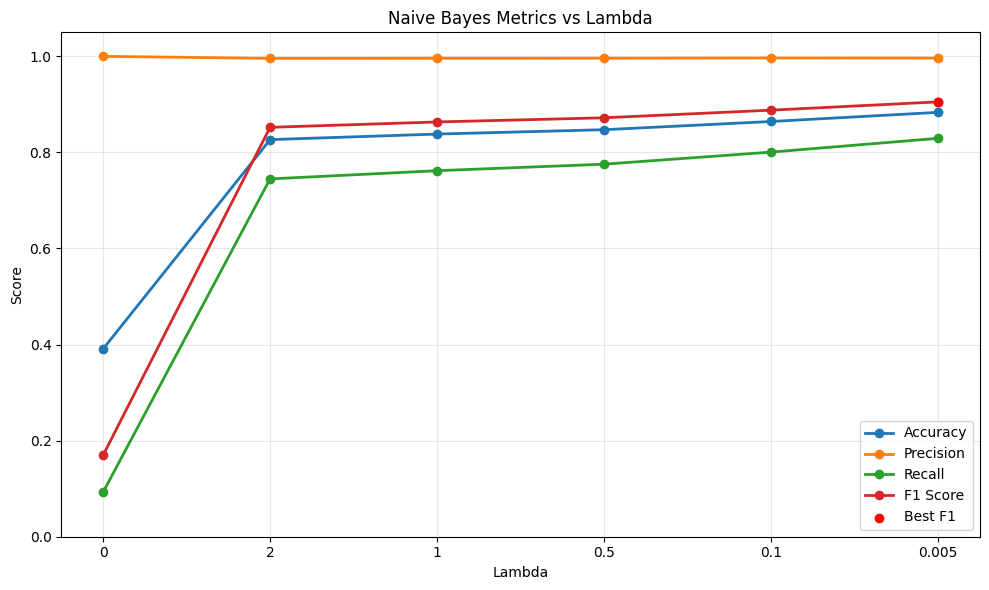

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

def tablegraph(allresults):
    df = pd.DataFrame(allresults)
    df["lambda"] = df["lambda"].map(lambda x: format(x, "g"))

    pd.set_option("display.float_format", "{:.4f}".format)
    pd.set_option("display.max_columns", None)
    print(df[["lambda", "topn", "tp", "tn", "fp", "fn", "accuracy", "precision", "recall", "f1"]].to_markdown(index=False))
    bestidx = df["f1"].idxmax()
    best = df.loc[bestidx]
    print(
        f"\nBest by F1: lambda={best['lambda']} Top-n={best['topn']}  "
        f"P={best['precision']:.4f}  R={best['recall']:.4f}  F1={best['f1']:.4f}"
    )
    return df

def plotgraph(df):
    bestidx = df["f1"].idxmax()  # recompute from df — not in scope from tablegraph
    x = list(range(len(df)))

    plt.figure(figsize=(10, 6))
    plt.plot(x, df["accuracy"],  marker="o", linewidth=2, label="Accuracy")
    plt.plot(x, df["precision"], marker="o", linewidth=2, label="Precision")
    plt.plot(x, df["recall"],    marker="o", linewidth=2, label="Recall")
    plt.plot(x, df["f1"],        marker="o", linewidth=2, label="F1 Score")
    plt.scatter([bestidx], [df.loc[bestidx, "f1"]], color="red", zorder=5, label="Best F1")

    plt.xticks(x, df["lambda"])
    plt.xlabel("Lambda")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.title("Naive Bayes Metrics vs Lambda")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

preliminary = tablegraph(allresults)
plotgraph(preliminary)

# 7. Results of the Test

## Preliminary Results
```
True (Ham)  : 3,755
 True (Spam) : 7,667
```
|   lambda | topn   |   tp |   tn |   fp |   fn |   accuracy |   precision |    recall |       f1 |
|---------:|:-------|-----:|-----:|-----:|-----:|-----------:|------------:|----------:|---------:|
|    0     | ---    |  709 | 3755 |    0 | 6958 |   0.390825 |    1        | 0.0924742 | 0.169293 |
|    2     | ---    | 5711 | 3731 |   24 | 1956 |   0.82665  |    0.995815 | 0.744881  | 0.852261 |
|    1     | ---    | 5842 | 3732 |   23 | 1825 |   0.838207 |    0.996078 | 0.761967  | 0.863435 |
|    0.5   | ---    | 5946 | 3732 |   23 | 1721 |   0.847312 |    0.996147 | 0.775531  | 0.872103 |
|    0.1   | ---    | 6139 | 3734 |   21 | 1528 |   0.864385 |    0.996591 | 0.800704  | 0.887973 |
|    0.005 | ---    | 6359 | 3732 |   23 | 1308 |   0.88347  |    0.996396 | 0.829399  | 0.90526  |

Best by F1: lambda=0.005 Top-n=---  P=0.9964  R=0.8294  F1=0.9053

The precision scores for no smoothing is perfect at 1.0. This is because it is conservatively defaulting to `ham` when there are unknown words. This leads to very high false positives, leading to a low precision of 0.3505.

The best score is when $lambda=0.005$ where $F_1$ score significantly increased to 0.90526. It was highlighted that having any lambda value will introduce some False Positives, but with the tradeoff of having really good Recall.


## Improvements: Looking for the ideal word-count (`topn`) value that optimizes $F_1$ score

Hovold suggests removing frequent words (for example, "a" and "the") to reduce noise and improve precision under the same threshold and smoothing settings.

Setting `topn = 200` refines the vocabulary to keep more discriminative terms. Run the code below to initialize `topwords`.

**Note:** Words produced from number and URL transformations in the email parser are excluded from this stopword-removal list.



In [20]:
import copy

def topwords(topn, vocabs, protectedwords=None):
    defaultprotected = {"url", "emailaddr", "multiexclaim", "price", "num", "attachment"}
    if protectedwords is None:
        protectedwords = defaultprotected

    filteredvocabs = copy.copy(vocabs)
    filteredvocabs.hamwords  = copy.copy(vocabs.hamwords)
    filteredvocabs.spamwords = copy.copy(vocabs.spamwords)
    filteredvocabs.Vham      = copy.copy(vocabs.Vham)
    filteredvocabs.Vspam     = copy.copy(vocabs.Vspam)

    combined = filteredvocabs.hamwords + filteredvocabs.spamwords
    candidates = [
        w for w, _ in combined.most_common()
        if w not in protectedwords
    ]
    removedwords = set(candidates[:topn])  # renamed — no longer shadows the function

    filteredvocabs.Vham  -= removedwords
    filteredvocabs.Vspam -= removedwords
    for word in removedwords:
        filteredvocabs.hamwords.pop(word, None)
        filteredvocabs.spamwords.pop(word, None)

    # print(f"[topwords] Removed {len(removedwords)} words from whole vocabulary.")
    # print(f"[topwords] Protected words: {protectedwords}")
    print(f"[topwords] Refined |Vham|={len(filteredvocabs.Vham):,}  |Vspam|={len(filteredvocabs.Vspam):,}")
    print(f"[topwords] Filtered words: {removedwords}\n")

    return filteredvocabs, removedwords

In [21]:
topn = [200, 100]
LAMBDAVAL = 0.005 #fixed
THRESHOLD = 0.5 #for testing
PROGRESS_EVERY = 0 #for testing

testemails = training_vocabs.alltestemails
ytrue = [r["label"] for r in testemails]
cleantexts = [r["clean"] for r in testemails]
total = len(cleantexts)

hovoldresults = allresults

for x in topn:
    hovold_vocabs, removedwords = topwords(x, training_vocabs)  # x not topn, removedwords not topwords
    print(f"[topwords] Filtered words: {removedwords}")

    pham, pspam = priors(hovold_vocabs)
    dham, dspam = denom(hovold_vocabs, LAMBDAVAL)
    print(f"P(ham) new = {pham:.4f}  P(spam) new = {pspam:.4f}")
    print(f"D(ham) new = {dham}  D(spam) new = {dspam}")

    ypred = []
    counts = {"tp": 0, "tn": 0, "fp": 0, "fn": 0, "spam": 0, "ham": 0}
    print(f"\n[topn={x}] Classifying {total:,} emails...")  # x not topn

    for idx, (cleantext, truelabel) in enumerate(zip(cleantexts, ytrue), start=1):
        predlabel, _, _, _ = classify(
            cleantext, hovold_vocabs, LAMBDAVAL, dham, dspam,  
            threshold=THRESHOLD, alreadyclean=True,
        )
        ypred.append(predlabel)
        updatecounts(predlabel, truelabel, counts)

        if PROGRESS_EVERY and idx % PROGRESS_EVERY == 0 or len(ypred) == total:
            p = counts["tp"] / (counts["tp"] + counts["fp"]) if (counts["tp"] + counts["fp"]) > 0 else 0.0
            r = counts["tp"] / (counts["tp"] + counts["fn"]) if (counts["tp"] + counts["fn"]) > 0 else 0.0
            print(f"  Processed {idx:,}/{total:,}...  P: {p:.4f}  R: {r:.4f}")

    result = Scores(ytrue, ypred)
    hovoldresults.append({
        "lambda": LAMBDAVAL,
        "topn": x,  # x not topn
        "tp": result.tp, "tn": result.tn, "fp": result.fp, "fn": result.fn,
        "accuracy": result.accuracy,
        "precision": result.precision,
        "recall": result.recall,
        "f1": result.f1_score,
    })
    result.print_scores()

print(f"Done processing test emails with topn values of {topn}.\n")

[topwords] Refined |Vham|=112,356  |Vspam|=40,907
[topwords] Filtered words: {'style', 'in', 'or', 'body', 'width', 'nil', 'me', 'like', 'on', 'was', 'so', 'all', 'to', 'will', 'l', 'mar', 'microsoft', 'html', 'x', 'received', 'arizona', 'plain', 'e', 'also', 'span', 'message', 'h', 'any', 'the', 'up', 'sep', 'more', 'br', 'strong', 'new', 'sat', 'height', 'information', 'do', '_', 'reply', 'their', 'our', 'how', 'ms', 'have', 'content', 'k', 'size', 'subject', 'est', 'dec', 'dmdx', 'am', 'align', 'q', 'adobe', 'com', 'r', 'then', 'very', 'version', 'just', 'o', 'mit', 'tue', 'time', 'could', 'div', 'aug', 'edu', 'text', 'at', 'using', 'they', 'jan', 'c', 'class', 'oct', 'id', 'date', 'washington', 'other', 'company', 'aa', 'some', 'what', 're', 'if', 'not', 'file', 'would', 'j', 'this', 'wed', 'windows', 'but', 'when', 'as', 'which', 'one', 'net', 'a', 'type', 'about', 'by', 'border', 'table', 'unknown', 'and', 'is', 't', 'board', 'mail', 'y', 'i', 'td', 'g', 'them', 'be', 'm', 'fri',

### When `top_n` is 200

Using the lambda value from the previous section:

```
LAMBDA_VAL = 0.005

 True (Ham)  : 3,755
 True (Spam) : 7,667
  TP=7,468  TN=3,630
  FP=125  FN=199
  Accuracy  : 0.9716
  Precision : 0.9835
  Recall    : 0.9740
  F1 Score  : 0.9788
```
These scores are substantially higher than earlier runs, with F1 Score reaching 0.9788. It was noted that False Positives are higher, which is not preferred, but more Spam was correctly identified.

### When `top_n` is 100

```
 True (Ham)  : 3,755
 True (Spam) : 7,667
  TP=7,477  TN=3,626
  FP=129  FN=190
  Accuracy  : 0.9721
  Precision : 0.9830
  Recall    : 0.9752
  F1 Score  : 0.9791
```

These scores are also much higher than earlier runs and are very close to `top_n = 200`. This is expected because the first 100 removed terms are mostly stopwords with limited predictive value. Removing additional frequent words produces only marginal gains and can slightly lower Precision.



|   lambda | topn   |   tp |   tn |   fp |   fn |   accuracy |   precision |    recall |       f1 |
|---------:|:-------|-----:|-----:|-----:|-----:|-----------:|------------:|----------:|---------:|
|    0     | ---    |  709 | 3755 |    0 | 6958 |   0.390825 |    1        | 0.0924742 | 0.169293 |
|    2     | ---    | 5711 | 3731 |   24 | 1956 |   0.82665  |    0.995815 | 0.744881  | 0.852261 |
|    1     | ---    | 5842 | 3732 |   23 | 1825 |   0.838207 |    0.996078 | 0.761967  | 0.863435 |
|    0.5   | ---    | 5946 | 3732 |   23 | 1721 |   0.847312 |    0.996147 | 0.775531  | 0.872103 |
|    0.1   | ---    | 6139 | 3734 |   21 | 1528 |   0.864385 |    0.996591 | 0.800704  | 0.887973 |
|    0.005 | ---    | 6359 | 3732 |   23 | 1308 |   0.88347  |    0.996396 | 0.829399  | 0.90526  |
|    0.005 | 200    | 7468 | 3630 |  125 |  199 |   0.971634 |    0.983537 | 0.974045  | 0.978768 |
|    0.005 | 100    | 7477 | 3626 |  129 |  190 |   0.972071 |    0.98304  | 0.975218  | 0.979113 |


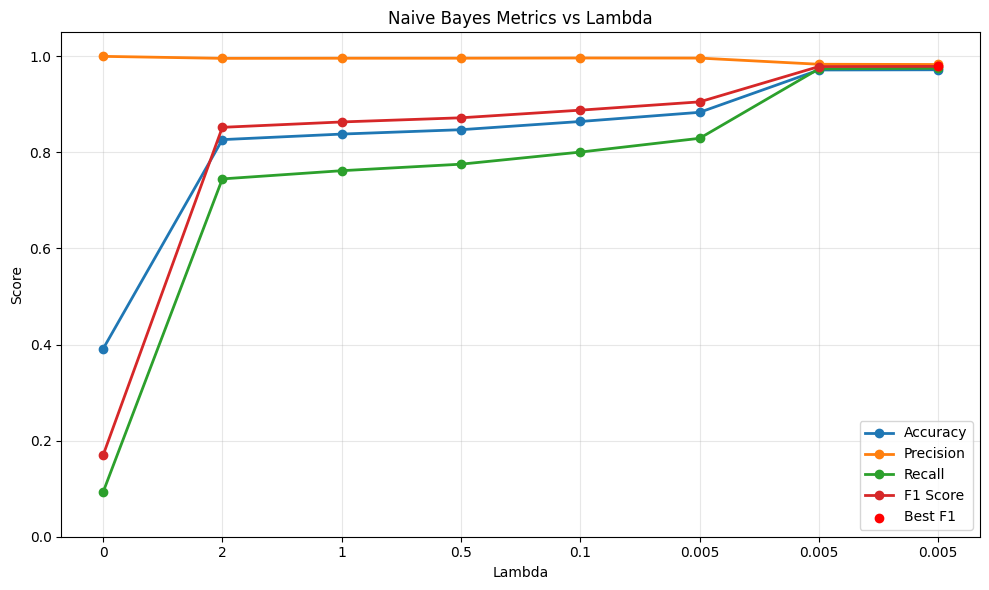

[topwords] Refined |Vham|=112,456  |Vspam|=41,005
[topwords] Filtered words: {'in', 'or', 'width', 'me', 'on', 'was', 'so', 'all', 'to', 'will', 'l', 'x', 'plain', 'e', 'h', 'any', 'the', 'more', 'br', 'do', 'our', 'have', 'k', 'size', 'est', 'com', 'r', 'o', 'mit', 'tue', 'edu', 'text', 'at', 'they', 'jan', 'c', 'id', 're', 'if', 'not', 'would', 'j', 'this', 'wed', 'but', 'as', 'one', 'net', 'a', 'by', 'and', 'is', 't', 'mail', 'y', 'i', 'td', 'g', 'be', 'm', 'fri', 'z', 'ufffd', 'smtp', 'an', 'u', 'from', 'it', 'my', 'are', 's', 'w', 'v', 'aleve', 'of', 'tr', 'can', 'color', 'd', 'we', 'nbsp', 'that', 'font', 'b', 'may', 'you', 'n', 'f', 'edt', 'there', 'mon', 'media', 'no', 'p', 'esmtp', 'your', 'thu', 'for', 'has', 'with'}

[topwords] Refined |Vham|=112,356  |Vspam|=40,907
[topwords] Filtered words: {'style', 'in', 'or', 'body', 'width', 'nil', 'me', 'like', 'on', 'was', 'so', 'all', 'to', 'will', 'l', 'mar', 'microsoft', 'html', 'x', 'received', 'arizona', 'plain', 'e', 'also', 's

In [22]:
finalgraph = tablegraph(hovoldresults)
plotgraph(finalgraph)

hovold_vocabs100, removedwords100 = topwords(100, training_vocabs)
hovold_vocabs200, removedwords200 = topwords(200, training_vocabs)

## Saving the model

Now that the model is finished, a new `model.csv` file can be created for future use. This will include the constants (priors, denoms) as well as the spam and ham vocabulary.

In [23]:
def save_model(vocabs, path="model.csv"):
    V = len(vocabs.Vham | vocabs.Vspam)
    sumham  = sum(vocabs.hamwords.values())
    sumspam = sum(vocabs.spamwords.values())

    # Metadata rows — stored as sentinel words for easy reconstruction
    metarows = [
        {"word": "__hamdocprior__",  "hamcount": vocabs.hamdocprior,  "spamcount": "",      "invham": "", "invspam": ""},
        {"word": "__spamdocprior__", "hamcount": vocabs.spamdocprior, "spamcount": "",      "invham": "", "invspam": ""},
        {"word": "__sumham__",       "hamcount": sumham,              "spamcount": "",      "invham": "", "invspam": ""},
        {"word": "__sumspam__",      "hamcount": "",                  "spamcount": sumspam, "invham": "", "invspam": ""},
        {"word": "__V__",            "hamcount": V,                   "spamcount": "",      "invham": "", "invspam": ""},
    ]

    # One row per word in the combined vocabulary
    allwords = sorted(set(vocabs.hamwords.keys()) | set(vocabs.spamwords.keys()))
    wordrows = [
        {
            "word":     word,
            "hamcount":  vocabs.hamwords.get(word, 0),
            "spamcount": vocabs.spamwords.get(word, 0),
            "invham":    int(word in vocabs.Vham),
            "invspam":   int(word in vocabs.Vspam),
        }
        for word in allwords
    ]

    df = pd.DataFrame(metarows + wordrows)
    df.to_csv(path, index=False)
    print(f"[savemodel] Saved {len(allwords):,} words + 5 metadata rows → {path}")

save_model(training_vocabs)


[savemodel] Saved 135,489 words + 5 metadata rows → model.csv


## Saving the Results

The new `results.csv` can also now be created so that output data can be used elsewhere.

In [24]:
# run this to save results.csv

def save_results(allresults, path="results.csv"):
    df = pd.DataFrame(allresults)
    df["lambda"] = df["lambda"].map(lambda x: format(x, "g"))
    df = df[["lambda", "topn", "tp", "tn", "fp", "fn", "accuracy", "precision", "recall", "f1"]]
    df.to_csv(path, index=False)
    print(f"[saveresults] Saved {len(df)} result rows → {path}")

save_results(hovoldresults, path="results.csv")

[saveresults] Saved 8 result rows → results.csv


# 8. Final Results and Conclusion

## Top Words Glossary (topn = 100)

| Category | Words | Why Removed |
|---|---|---|
| **Stop words** | `a`, `an`, `the`, `and`, `or`, `but`, `of`, `in`, `on`, `at`, `to`, `for`, `is`, `are`, `was`, `be`, `have`, `has`, `will`, `would`, `not`, `no`, `do`, `so`, `if`, `it`, `we`, `they`, `my`, `me`, `you`, `our`, `your`, `all`, `any`, `one`, `more`, `may`, `there`, `this`, `that`, `with`, `from`, `by`, `as`, `re`, `i` | Extremely common in both ham and spam — carry no discriminative signal |
| **Single letters** | `a`, `b`, `c`, `d`, `e`, `f`, `g`, `h`, `i`, `j`, `k`, `l`, `m`, `n`, `o`, `p`, `r`, `s`, `t`, `u`, `v`, `w`, `x`, `y`, `z` | Tokenization artifacts — no semantic meaning |
| **Days / months** | `mon`, `tue`, `wed`, `thu`, `fri`, `jan` | Appear in email headers universally — no spam signal |
| **Email / SMTP headers** | `smtp`, `esmtp`, `edt`, `est`, `mail`, `id`, `from` | Present in virtually every raw email header |
| **HTML tags / attributes** | `td`, `tr`, `br`, `nbsp`, `font`, `width`, `size`, `color`, `text`, `plain`, `media` | HTML boilerplate — appear in both ham and spam newsletters |
| **TLDs / domains** | `com`, `net`, `edu`, `mit` | Too universal across all emails |
| **Unicode artifact** | `ufffd` | UTF-8 replacement character `\ufffd` — encoding noise |
| **Ambiguous short tokens** | `aleve` | High frequency but domain-ambiguous |

## Top Words Glossary (topn = 200)

These are the 200 most frequent words removed from the vocabulary.

| Category | Words | Why Removed |
|---|---|---|
| **Stop words** | `a`, `an`, `the`, `and`, `or`, `but`, `of`, `in`, `on`, `at`, `to`, `for`, `is`, `are`, `was`, `be`, `have`, `has`, `will`, `would`, `not`, `no`, `do`, `so`, `if`, `it`, `we`, `they`, `my`, `me`, `you`, `our`, `your`, `all`, `any`, `one`, `more`, `may`, `there`, `this`, `that`, `with`, `from`, `by`, `as`, `re`, `i`, `he`, `its`, `their`, `also`, `been`, `should`, `could`, `which`, `then`, `when`, `some`, `them`, `about`, `other`, `only`, `just`, `very`, `out`, `up`, `see`, `get`, `like`, `now`, `how`, `here`, `what`, `send`, `use`, `using`, `please`, `know`, `need`, `help`, `don`, `am` | Extremely common in both ham and spam — carry no discriminative signal |
| **Single letters** | `a`, `b`, `c`, `d`, `e`, `f`, `g`, `h`, `i`, `j`, `k`, `l`, `m`, `n`, `o`, `p`, `q`, `r`, `s`, `t`, `u`, `v`, `w`, `x`, `y`, `z` | Tokenization artifacts — no semantic meaning |
| **Days of week** | `mon`, `tue`, `wed`, `thu`, `fri`, `sat`, `sun` | Appear in email headers universally — no spam signal |
| **Months** | `jan`, `feb`, `mar`, `apr`, `jul`, `aug`, `sep`, `oct`, `nov`, `dec` | Appear in email date headers universally — no spam signal |
| **Email / SMTP headers** | `smtp`, `esmtp`, `edt`, `est`, `mail`, `id`, `from`, `received`, `subject`, `date`, `reply`, `message`, `content`, `charset`, `multipart`, `alternative`, `unknown`, `nil` | Present in virtually every raw email header |
| **HTML tags / attributes** | `td`, `tr`, `br`, `nbsp`, `font`, `width`, `size`, `color`, `text`, `plain`, `media`, `div`, `span`, `table`, `html`, `body`, `style`, `class`, `border`, `align`, `center`, `href`, `face`, `strong`, `type`, `height`, `pt` | HTML boilerplate — appear in both ham and spam newsletters |
| **TLDs / domains** | `com`, `net`, `edu`, `mit`, `uw`, `de`, `ml`, `ms`, `aa` | Too universal across all emails |
| **Software / platform names** | `microsoft`, `windows`, `adobe`, `dmdx` | Generic platform references — appear across both classes |
| **Geographic names** | `washington`, `arizona` | Institution-specific tokens tied to dataset origin, not spam signal |
| **Unicode / encoding artifacts** | `ufffd`, `ufffdb`, `_` | UTF-8 replacement characters and tokenization noise |
| **Common email terms** | `email`, `list`, `file`, `number`, `version`, `information`, `time`, `new`, `board`, `company`, `gold` | High frequency but appear broadly across both classes |
| **Ambiguous short tokens** | `aleve`, `don`, `nil`, `aa`, `ms` | High frequency but domain-ambiguous or abbreviation noise |

The core problem these all share: they appear at roughly equal rates in ham and spam,
so their likelihood ratio P(word|spam) / P(word|ham) ≈ 1 — meaning they contribute
near-zero log-likelihood difference and only add noise to the classifier.

**Final Scores**

|   lambda | topn   |   tp |   tn |   fp |   fn |   accuracy |   precision |    recall |       f1 |
|---------:|:-------|-----:|-----:|-----:|-----:|-----------:|------------:|----------:|---------:|
|    0     | ---    |  709 | 3755 |    0 | 6958 |   0.390825 |    1        | 0.0924742 | 0.169293 |
|    2     | ---    | 5711 | 3731 |   24 | 1956 |   0.82665  |    0.995815 | 0.744881  | 0.852261 |
|    1     | ---    | 5842 | 3732 |   23 | 1825 |   0.838207 |    0.996078 | 0.761967  | 0.863435 |
|    0.5   | ---    | 5946 | 3732 |   23 | 1721 |   0.847312 |    0.996147 | 0.775531  | 0.872103 |
|    0.1   | ---    | 6139 | 3734 |   21 | 1528 |   0.864385 |    0.996591 | 0.800704  | 0.887973 |
|    0.005 | ---    | 6359 | 3732 |   23 | 1308 |   0.88347  |    0.996396 | 0.829399  | 0.90526  |
|    0.005 | 200    | 7468 | 3630 |  125 |  199 |   0.971634 |    0.983537 | 0.974045  | 0.978768 |
|    0.005 | 100    | 7477 | 3626 |  129 |  190 |   0.972071 |    0.98304  | 0.975218  | 0.979113 |

Best by F1: lambda=0.005 Top-n=100  P=0.9830  R=0.9752  F1=0.9791


Overall, the best $F_1$ score with a strong Precision-Recall balance is achieved at $\lambda = 0.005$ and `top_n = 100`. A higher Precision score is preferred to limit `ham` emails incorrectly classify as `spam`.

The weakest setting is no smoothing ($\lambda = 0$), with an $F_1$ score of 0.1692.

# 9. Recommendations

Additional threshold experiments may still improve results. Very low thresholds increase the $F_1$ score, but the `topn`-based word removal method currently yields stronger overall performance.